C:\Users\charl\AppData\Local\Temp\ipykernel_15240\850639041.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_sex = df.groupby('성별').apply(lambda x: x[['AA8SA_1', 'AA8SA_2']].mean())
C:\Users\charl\AppData\Local\Temp\ipykernel_15240\850639041.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_age = df.groupby('연령').apply(lambda x: x[['AA8SA_1', 'AA8SA_2']].mean())


        국내 항공사 (%)  외국 항공사 (%)
구분                            
전체            68.4        31.6
남자            69.0        31.0
여자            67.9        32.1
15~19세        84.6        15.4
20대           65.3        34.7
30대           69.7        30.3
40대           71.1        28.9
50대           66.5        33.5
60대           69.4        30.6
70세 이상        64.3        35.7


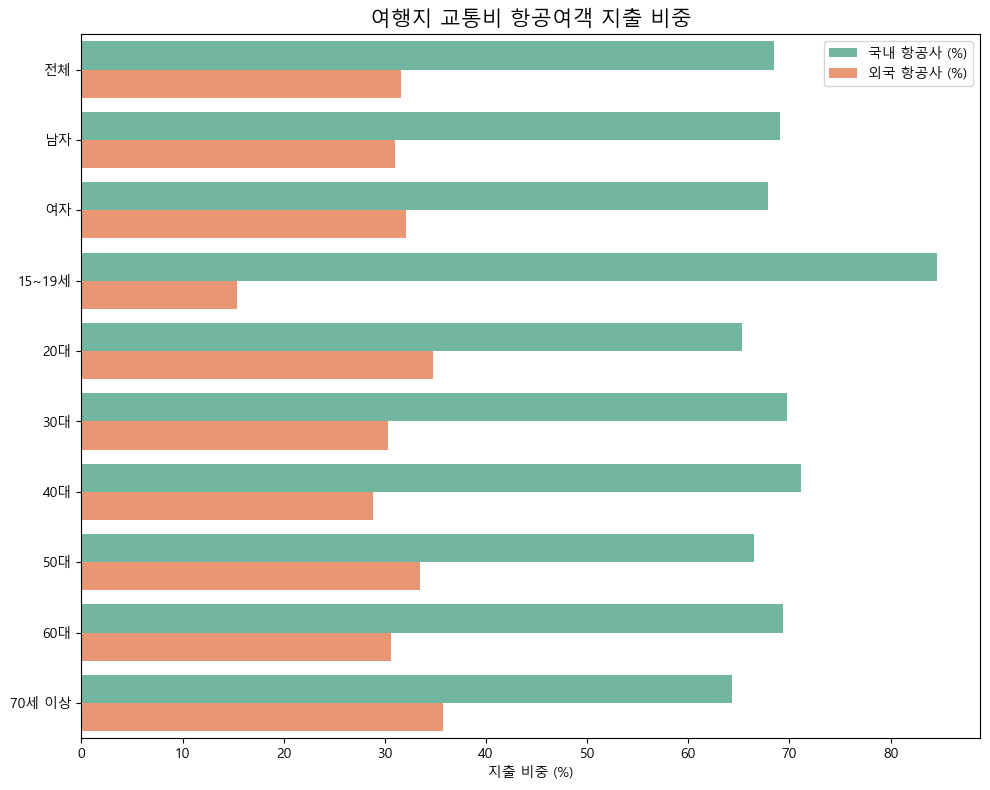

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------
# 1) 데이터 읽기 ― 필요한 컬럼만 부분 로드
# -------------------------------------------------
use_cols = ['BSEX', 'BAGE', 'AA8SA_1', 'AA8SA_2']
df = pd.read_excel(
    './data/2024_해외.xlsx',
    sheet_name='RAWDATA',
    header=1,           # 2번째 줄이 컬럼명
    usecols=use_cols
)

# -------------------------------------------------
# 2) 전처리 : 결측 제거‧라벨 매핑
# -------------------------------------------------
df = df.dropna(subset=['AA8SA_1', 'AA8SA_2'])          # 비율값이 없는 행 제외

sex_map = {1: '남자', 2: '여자'}
age_map = {
    1: '15~19세', 2: '20대', 3: '30대', 4: '40대',
    5: '50대', 6: '60대', 7: '70세 이상'
}

df['성별'] = df['BSEX'].map(sex_map)
df['연령'] = df['BAGE'].map(age_map)

# -------------------------------------------------
# 3) 요약 테이블 만들기
# -------------------------------------------------
def summary_table(grp, label):
    """그룹(Series) → 평균 비율 반환"""
    sub = df.loc[grp][['AA8SA_1', 'AA8SA_2']].mean()
    sub.name = label
    return sub

# (1) 전체
overall = summary_table(df.index, '전체')

# (2) 성별
by_sex = df.groupby('성별').apply(lambda x: x[['AA8SA_1', 'AA8SA_2']].mean())

# (3) 연령
by_age = df.groupby('연령').apply(lambda x: x[['AA8SA_1', 'AA8SA_2']].mean())

# (4) 하나로 concat → 최종 표 형태
table = pd.concat([overall.to_frame().T, by_sex, by_age])
table.columns = ['국내 항공사 (%)', '외국 항공사 (%)']
table.index.name = '구분'

print(table.round(1))          # 표 3-2-25와 유사한 수치 확인

# -------------------------------------------------
# 4) 시각화 : 그룹화한 막대그래프(국내 vs 외국)
# -------------------------------------------------
plt.rcParams['font.family'] = 'Malgun Gothic'     # ✅ 윈도우용 폰트 설정
plt.rcParams['axes.unicode_minus'] = False         # 마이너스 기호 깨짐 방지

# seaborn용 tidy 형태로 변환
plot_df = (
    table.reset_index()
         .melt(id_vars='구분', var_name='항공사', value_name='비율')
)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=plot_df,
    x='비율', y='구분',
    hue='항공사', orient='h',
    palette='Set2'
)

plt.title('여행지 교통비 항공여객 지출 비중', fontsize=15)
plt.xlabel('지출 비중 (%)')
plt.ylabel('')
plt.legend(title='')
plt.tight_layout()
plt.savefig('airline_share_by_demo.png', dpi=300)
plt.show()
